# Tournament evaluation — Human-aligned cheat detector (binary)

This notebook **loads pre-trained binary classifiers** (same architectures/weights as in the training notebook) and evaluates them on a **tournament (test-only) dataset** with:

- `move_uci` (the played move)
- `move_label` (`0`=human, `1`=cheat)
- `is_used` (row eligibility mask)
- `player_elo` (to build 3 rating bins: Weak / Medium / Strong)  

Outputs:
- Per-model **metric tables** (rows = `Weak, Medium, Strong, ALL`; columns = models)
- Per-bin **classification_report** files
- Heatmaps saved to `OUT_DIR/curves/`


In [1]:
# === Imports / seeds ===
from __future__ import annotations

import json
import math
import os
import random
import subprocess
from pathlib import Path
from typing import Any, Dict, List, Tuple

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import classification_report

# Repro
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)


DEVICE: cuda


In [2]:
# === Config ===

def get_repo_root_git() -> Path:
    p = subprocess.check_output(["git", "rev-parse", "--show-toplevel"], text=True).strip()
    return Path(p)

REPO_ROOT = get_repo_root_git()
print("REPO_ROOT:", REPO_ROOT)

# ---- Tournament dataset ----
TOURNAMENT_CSV_PATH = REPO_ROOT / "data/interim/tournament/02_pov_tournament.csv"  # TODO
TOURNAMENT_EMB_NPZ  = REPO_ROOT / "data/processed/tournament" / "04_embs_allie_2500.npz"  # TODO
EMB_KEY = "move_uci"  # embeddings key inside NPZ (must be (N, D))

# If your CSV stores NPZ row ids in a saved index column (common: 'Unnamed: 0'),
# set NPZ_ROW_COL to that column name. If None, the notebook will:
#   - use 'Unnamed: 0' if present
#   - else assume row order matches NPZ (requires len(df)==len(npz[EMB_KEY]))
NPZ_ROW_COL: str | None = None  # TODO (optional)

# ---- Trained models to evaluate (produced by the training notebook) ----
# Point this to the *training run* output dir that contains:
#   - tables/selected_models.csv
#   - models/<cheat_name>/<run_id>/model.pt
TRAIN_RUN_OUT_DIR = REPO_ROOT / "new_notebooks/new_reports/03_2cls_6bins" / "allie_2500_for_trasnfer"  # TODO

SELECTED_MODELS_CSV = TRAIN_RUN_OUT_DIR / "tables/selected_models.csv"

# Optional: restrict to a subset of model names (None = all from selected_models.csv)
EVAL_MODEL_NAMES: list[str] | None = None

# Architectures available (run_id -> spec). Must match the training notebook.
DEFAULT_FIXED_SPECS: Dict[str, Dict[str, Any]] = {
    "mlp_002": {"hidden_dim": 256, "act": "GELU", "norm": "batch", "drop": 0.0, "lr": 3e-4, "weight_decay": 3e-4},
}

# ---- Elo bins (5 bins + ALL) ----
ELO_BINS = [
    ("<1.6k",       -math.inf, 1600),
    ("1.6-1.8k",    1600,      1800),
    ("1.8-2.0k",    1800,      2000),
    ("2.0-2.2k",    2000,      2200),
    (">2.2k",       2200,      math.inf),
]

# ---- Outputs ----
OUT_DIR = REPO_ROOT / "new_notebooks/new_reports/04_tournament_eval_2cls" / "allie_2500_for_transfer" # TODO
(OUT_DIR / "tables").mkdir(parents=True, exist_ok=True)
(OUT_DIR / "curves").mkdir(parents=True, exist_ok=True)

print("TOURNAMENT_CSV_PATH:", TOURNAMENT_CSV_PATH)
print("TOURNAMENT_EMB_NPZ :", TOURNAMENT_EMB_NPZ)
print("SELECTED_MODELS_CSV:", SELECTED_MODELS_CSV)
print("OUT_DIR:", OUT_DIR)


REPO_ROOT: /home/jovyan/artem/humanlike
TOURNAMENT_CSV_PATH: /home/jovyan/artem/humanlike/data/interim/tournament/02_pov_tournament.csv
TOURNAMENT_EMB_NPZ : /home/jovyan/artem/humanlike/data/processed/tournament/04_embs_allie_2500.npz
SELECTED_MODELS_CSV: /home/jovyan/artem/humanlike/new_notebooks/new_reports/03_2cls_6bins/allie_2500_for_trasnfer/tables/selected_models.csv
OUT_DIR: /home/jovyan/artem/humanlike/new_notebooks/new_reports/04_tournament_eval_2cls/allie_2500_for_transfer


In [3]:
# === Load tournament CSV + embeddings ===

if not TOURNAMENT_CSV_PATH.exists():
    raise FileNotFoundError(f"CSV not found: {TOURNAMENT_CSV_PATH}")
if not TOURNAMENT_EMB_NPZ.exists():
    raise FileNotFoundError(f"NPZ not found: {TOURNAMENT_EMB_NPZ}")

df = pd.read_csv(TOURNAMENT_CSV_PATH)

# Minimal required columns for this eval
REQ_COLS = ["is_used", "move_label", "player_elo", "move_uci"]
missing = [c for c in REQ_COLS if c not in df.columns]
if missing:
    raise KeyError(f"Missing required columns ({len(missing)}): {missing}")

# Load NPZ
npz = np.load(TOURNAMENT_EMB_NPZ)
if EMB_KEY not in npz.files:
    raise KeyError(f"NPZ is missing key '{EMB_KEY}'. Available keys (first 30): {list(npz.files)[:30]}")
emb_all = np.asarray(npz[EMB_KEY])
if emb_all.ndim != 2:
    raise ValueError(f"Expected npz['{EMB_KEY}'] to be 2D (N,D). Got shape={emb_all.shape}")

n_npz = int(emb_all.shape[0])
n_csv = int(len(df))

# Resolve mapping from CSV rows -> NPZ rows
npz_row_col = NPZ_ROW_COL
if npz_row_col is None:
    if "Unnamed: 0" in df.columns:
        npz_row_col = "Unnamed: 0"

if npz_row_col is not None:
    if npz_row_col not in df.columns:
        raise KeyError(f"NPZ_ROW_COL='{npz_row_col}' not found in CSV columns.")
    npz_rows = df[npz_row_col].to_numpy()
    if not np.issubdtype(npz_rows.dtype, np.integer):
        raise TypeError(f"NPZ row ids column '{npz_row_col}' must be integer dtype. Got {npz_rows.dtype}")
    if npz_rows.min() < 0 or npz_rows.max() >= n_npz:
        raise IndexError(
            f"CSV->NPZ indices out of range: [{int(npz_rows.min())}, {int(npz_rows.max())}] vs n_npz={n_npz}"
        )
else:
    # assume row order matches
    if n_npz != n_csv:
        raise ValueError(
            "Cannot align CSV rows to NPZ rows."
            f"- len(CSV)={n_csv}"
            f"- NPZ['{EMB_KEY}'] has n={n_npz}"
            "Provide NPZ_ROW_COL or ensure row order matches."
        )
    npz_rows = np.arange(n_csv, dtype=np.int64)

# Attach mapping for debugging
df["npz_row"] = npz_rows.astype(np.int64)

print("CSV rows:", n_csv)
print("NPZ rows:", n_npz)
print("emb_all:", emb_all.shape, emb_all.dtype)
print("is_used:", df["is_used"].value_counts(dropna=False).to_dict())

df.head(5)

CSV rows: 77020
NPZ rows: 77020
emb_all: (77020, 1024) float16
is_used: {False: 48610, True: 28410}


,tournament_id,game_id,game_result,time_control,player,player_color,player_elo,opponent_elo,half_move,move_uci,fen_before,fen_after,move_label,move_thinking_time,player_engine_hints,player_cheat_depth,cheat_engine_line,is_used,npz_row
0,ciEM2t5a,01zsFrq4_w,0.5-0.5,300+0,player_37,white,1883,2191,1,e2e4,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR ...,0,0.000000,NaN,14,NaN,False,0
1,ciEM2t5a,01zsFrq4_w,0.5-0.5,300+0,player_37,white,1883,2191,2,c7c6,rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR ...,rnbqkbnr/pp1ppppp/2p5/8/4P3/8/PPPP1PPP/RNBQKBN...,0,0.766277,NaN,14,NaN,False,1
2,ciEM2t5a,01zsFrq4_w,0.5-0.5,300+0,player_37,white,1883,2191,3,d2d4,rnbqkbnr/pp1ppppp/2p5/8/4P3/8/PPPP1PPP/RNBQKBN...,rnbqkbnr/pp1ppppp/2p5/8/3PP3/8/PPP2PPP/RNBQKBN...,0,2.381436,NaN,14,NaN,False,2
3,ciEM2t5a,01zsFrq4_w,0.5-0.5,300+0,player_37,white,1883,2191,4,d7d5,rnbqkbnr/pp1ppppp/2p5/8/3PP3/8/PPP2PPP/RNBQKBN...,rnbqkbnr/pp2pppp/2p5/3p4/3PP3/8/PPP2PPP/RNBQKB...,0,0.458574,NaN,14,NaN,False,3
4,ciEM2t5a,01zsFrq4_w,0.5-0.5,300+0,player_37,white,1883,2191,5,e4d5,rnbqkbnr/pp2pppp/2p5/3p4/3PP3/8/PPP2PPP/RNBQKB...,rnbqkbnr/pp2pppp/2p5/3P4/3P4/8/PPP2PPP/RNBQKBN...,0,0.186251,NaN,14,NaN,False,4


In [4]:
# === Filter is_used + build Elo bins (Weak/Medium/Strong) ===

df_f = df.loc[df["is_used"] == True].reset_index(drop=True)

# Validate labels
y_full = df_f["move_label"].to_numpy()
if pd.isna(y_full).any():
    raise ValueError("move_label contains NA after is_used filtering.")
uniq = np.unique(y_full)
if not set(uniq.tolist()).issubset({0, 1}):
    raise ValueError(f"move_label must be binary 0/1. Found unique: {uniq.tolist()}")

# Build elo_bin
elo = df_f["player_elo"].to_numpy(dtype=np.int64)

bin_names: list[str] = []
for name, lo, hi in ELO_BINS:
    bin_names.append(name)

elo_bin = np.empty(len(df_f), dtype=object)
for name, lo, hi in ELO_BINS:
    mask = (elo >= lo) & (elo < hi)
    elo_bin[mask] = name

if (pd.isna(elo_bin)).any():
    # should never happen because bins cover (-inf, inf)
    bad = np.flatnonzero(pd.isna(elo_bin))[:10]
    raise RuntimeError(f"Unassigned elo_bin rows (showing up to 10): {bad.tolist()}")

df_f["elo_bin"] = pd.Series(elo_bin, dtype="string")

# Slice embeddings aligned with df_f
npz_rows_f = df_f["npz_row"].to_numpy(dtype=np.int64)
X_emb = emb_all[npz_rows_f].astype(np.float32, copy=False)

print("Filtered rows:", len(df_f))
print("elo_bin counts:", df_f["elo_bin"].value_counts(dropna=False).to_dict())
print("X_emb:", X_emb.shape, X_emb.dtype)

df_f.head(5)


Filtered rows: 28410
elo_bin counts: {'>2.2k': 8316, '1.8-2.0k': 6348, '2.0-2.2k': 5794, '1.6-1.8k': 4815, '<1.6k': 3137}
X_emb: (28410, 1024) float32


,tournament_id,game_id,game_result,time_control,player,player_color,player_elo,opponent_elo,half_move,move_uci,fen_before,fen_after,move_label,move_thinking_time,player_engine_hints,player_cheat_depth,cheat_engine_line,is_used,npz_row,elo_bin
0,ciEM2t5a,01zsFrq4_w,0.5-0.5,300+0,player_37,white,1883,2191,21,f4g5,r2qk2r/pp3p1p/2nbpn2/3p1p2/3P1B2/2P2N2/PP1N1PP...,r2qk2r/pp3p1p/2nbpn2/3p1pB1/3P4/2P2N2/PP1N1PPP...,1,2.871923,NaN,14,1.0,True,20,1.8-2.0k
1,ciEM2t5a,01zsFrq4_w,0.5-0.5,300+0,player_37,white,1883,2191,23,f1e1,r2qk1r1/pp3p1p/2nbpn2/3p1pB1/3P4/2P2N2/PP1N1PP...,r2qk1r1/pp3p1p/2nbpn2/3p1pB1/3P4/2P2N2/PP1N1PP...,1,4.115187,NaN,14,2.0,True,22,1.8-2.0k
2,ciEM2t5a,01zsFrq4_w,0.5-0.5,300+0,player_37,white,1883,2191,25,f3g5,r2qk3/pp3p1p/2nbpn2/3p1pr1/3P4/2P2N2/PP1N1PPP/...,r2qk3/pp3p1p/2nbpn2/3p1pN1/3P4/2P5/PP1N1PPP/R2...,1,1.923551,NaN,14,1.0,True,24,1.8-2.0k
3,ciEM2t5a,01zsFrq4_w,0.5-0.5,300+0,player_37,white,1883,2191,27,g1h2,r2qk3/pp3p1p/2n1pn2/3p1pN1/3P4/2P5/PP1N1PPb/R2...,r2qk3/pp3p1p/2n1pn2/3p1pN1/3P4/2P5/PP1N1PPK/R2...,1,1.509984,NaN,14,1.0,True,26,1.8-2.0k
4,ciEM2t5a,01zsFrq4_w,0.5-0.5,300+0,player_37,white,1883,2191,29,h2g1,r2qk3/pp3p1p/2n1p3/3p1pN1/3P2n1/2P5/PP1N1PPK/R...,r2qk3/pp3p1p/2n1p3/3p1pN1/3P2n1/2P5/PP1N1PP1/R...,1,3.232888,NaN,14,1.0,True,28,1.8-2.0k


In [5]:
# === Load selected models (same set as trained in the training notebook) ===

if not SELECTED_MODELS_CSV.exists():
    raise FileNotFoundError(
        f"selected_models.csv not found: {SELECTED_MODELS_CSV}\n"
        "Point TRAIN_RUN_OUT_DIR to the directory produced by the training notebook."
    )

selected_df = pd.read_csv(SELECTED_MODELS_CSV)

need_cols = ["cheat_name", "selected_run_id", "best_thr", "model_path"]
missing = [c for c in need_cols if c not in selected_df.columns]
if missing:
    raise KeyError(f"selected_models.csv missing columns: {missing}")

if EVAL_MODEL_NAMES is not None:
    selected_df = selected_df.loc[selected_df["cheat_name"].isin(EVAL_MODEL_NAMES)].reset_index(drop=True)

if len(selected_df) == 0:
    raise ValueError("No models selected for evaluation (selected_df is empty).")

def resolve_model_path(cheat_name: str, run_id: str, model_path_str: str) -> Path:
    # 1) as stored
    p = Path(model_path_str)
    if p.exists():
        return p

    # 2) relative to repo root
    p2 = (REPO_ROOT / model_path_str).resolve()
    if p2.exists():
        return p2

    # 3) canonical location under the training run dir
    p3 = TRAIN_RUN_OUT_DIR / "models" / cheat_name / run_id / "model.pt"
    if p3.exists():
        return p3

    raise FileNotFoundError(
        "Cannot resolve model path.\n"
        f"cheat_name={cheat_name} run_id={run_id}\n"
        f"model_path_str={model_path_str}\n"
        f"Tried: {p}, {p2}, {p3}"
    )

# Build evaluation list
models: list[dict[str, Any]] = []
for row in selected_df.to_dict(orient="records"):
    cheat_name = str(row["cheat_name"])
    run_id = str(row["selected_run_id"])
    if run_id not in DEFAULT_FIXED_SPECS:
        raise KeyError(
            f"run_id='{run_id}' not found in DEFAULT_FIXED_SPECS. "
            f"Available: {list(DEFAULT_FIXED_SPECS.keys())}"
        )

    model_path = resolve_model_path(cheat_name, run_id, str(row["model_path"]))
    models.append({
        "cheat_name": cheat_name,
        "run_id": run_id,
        "spec": DEFAULT_FIXED_SPECS[run_id],
        "thr": float(row["best_thr"]),
        "model_path": model_path,
    })

print("Loaded models:", len(models))
pd.DataFrame(models)[["cheat_name", "run_id", "thr", "model_path"]].head(20)


Loaded models: 9


,cheat_name,run_id,thr,model_path
0,ALL,mlp_002,0.5,/home/jovyan/artem/humanlike/new_notebooks/new...
1,lc0_1,mlp_002,0.5,/home/jovyan/artem/humanlike/new_notebooks/new...
2,lc0_10,mlp_002,0.5,/home/jovyan/artem/humanlike/new_notebooks/new...
3,lc0_100,mlp_002,0.5,/home/jovyan/artem/humanlike/new_notebooks/new...
4,stockfish_1,mlp_002,0.5,/home/jovyan/artem/humanlike/new_notebooks/new...
5,stockfish_11,mlp_002,0.5,/home/jovyan/artem/humanlike/new_notebooks/new...
6,stockfish_15,mlp_002,0.5,/home/jovyan/artem/humanlike/new_notebooks/new...
7,stockfish_5,mlp_002,0.5,/home/jovyan/artem/humanlike/new_notebooks/new...
8,stockfish_9,mlp_002,0.5,/home/jovyan/artem/humanlike/new_notebooks/new...


In [6]:
# === Model + metrics helpers (same as training notebook) ===

def build_mlp(
    input_dim: int,
    out_dim: int,
    *,
    hidden_dim: int,
    act: str,
    norm: str | None,
    drop: float,
) -> nn.Module:
    layers: List[nn.Module] = [nn.Linear(input_dim, hidden_dim)]

    if norm == "layer":
        layers.append(nn.LayerNorm(hidden_dim))
    elif norm == "batch":
        layers.append(nn.BatchNorm1d(hidden_dim))
    elif norm is None:
        pass
    else:
        raise ValueError(f"Unknown norm: {norm}")

    if act == "ReLU":
        layers.append(nn.ReLU())
    elif act == "GELU":
        layers.append(nn.GELU())
    elif act == "LeakyReLU":
        layers.append(nn.LeakyReLU(0.1))
    else:
        raise ValueError(f"Unknown activation: {act}")

    if drop > 0:
        layers.append(nn.Dropout(drop))

    layers.append(nn.Linear(hidden_dim, out_dim))
    return nn.Sequential(*layers)


@torch.no_grad()
def predict_proba(model: nn.Module, X: torch.Tensor) -> np.ndarray:
    """p(cheat=1) for binary model that outputs a single logit per sample."""
    model.eval()
    logits = model(X)                # (N,)
    logits = logits.view(-1)         # (N,)
    p = torch.sigmoid(logits)
    return p.detach().cpu().numpy()  # (N,)

def apply_threshold(p_pos: np.ndarray, thr: float):
    return (p_pos >= float(thr)).astype(np.int64)

def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "micro_f1": float(f1_score(y_true, y_pred, average="micro")),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro")),
        "cheat_precision": float(precision_score(y_true, y_pred, average="binary",  pos_label=1)),
        "cheat_recall": float(recall_score(y_true, y_pred, average="binary", pos_label=1)),
        "cheat_f1": float(f1_score(y_true, y_pred, average="binary", pos_label=1)),
    }


@torch.no_grad()
def eval_one_with_pred(
    *,
    model_path: Path,
    spec: dict[str, Any],
    thr: float,
    X: np.ndarray,
    y: np.ndarray,
) -> tuple[dict[str, float], np.ndarray]:
    X_t = torch.from_numpy(X).to(DEVICE, dtype=torch.float32, non_blocking=True)

    input_dim = int(X.shape[1])
    model = build_mlp(
        input_dim,
        1,
        hidden_dim=int(spec["hidden_dim"]),
        act=str(spec["act"]),
        norm=spec["norm"],
        drop=float(spec["drop"]),
    ).to(DEVICE)

    state = torch.load(model_path, map_location="cpu")
    model.load_state_dict(state, strict=True)

    probs = predict_proba(model, X_t)
    y_pred = apply_threshold(probs, thr=float(thr))

    metrics = compute_metrics(y, y_pred)
    return metrics, y_pred


In [7]:
# === Evaluation: metrics tables (rows = Weak/Medium/Strong/ALL, cols = models) ===

CLASS_LABELS = [0, 1]
CLASS_NAMES = ["human", "cheat"]

ALL_ROWS = [b[0] for b in ELO_BINS] + ["ALL"]
ALL_COLS = [m["cheat_name"] for m in models]

metric_names = [
    "accuracy",
    "micro_f1",
    "macro_f1",
    "cheat_precision",
    "cheat_recall",
    "cheat_f1",
]

tables: dict[str, pd.DataFrame] = {
    m: pd.DataFrame(index=ALL_ROWS, columns=ALL_COLS, dtype=float) for m in metric_names
}

y = df_f["move_label"].to_numpy(dtype=np.int64)

# Precompute bin -> rows indices
rows_by_bin: dict[str, np.ndarray] = {}
for b in [bb[0] for bb in ELO_BINS]:
    rows = np.flatnonzero(df_f["elo_bin"].to_numpy() == b)
    if rows.size == 0:
        raise ValueError(f"No rows for elo_bin='{b}' after is_used filtering.")
    rows_by_bin[b] = rows
rows_by_bin["ALL"] = np.arange(len(df_f), dtype=np.int64)

for m in models:
    name = str(m["cheat_name"])
    spec = m["spec"]
    thr = float(m["thr"])
    model_path = Path(m["model_path"])

    for row_name in ALL_ROWS:
        rows = rows_by_bin[row_name]
        X_part = X_emb[rows]
        y_part = y[rows]

        metrics, y_pred = eval_one_with_pred(
            model_path=model_path,
            spec=spec,
            thr=thr,
            X=X_part,
            y=y_part,
        )

        for mn in metric_names:
            tables[mn].loc[row_name, name] = float(metrics.get(mn, np.nan))

        rep = classification_report(
            y_part,
            y_pred,
            labels=CLASS_LABELS,
            target_names=CLASS_NAMES,
            digits=2,
            zero_division=0,
        )
        print(f"\n=== classification_report | model={name} | bin={row_name} ===\n{rep}")

        out_dir = OUT_DIR / "tables" / "classification_report"
        out_dir.mkdir(parents=True, exist_ok=True)
        (out_dir / f"{name}__{row_name}.txt").write_text(rep, encoding="utf-8")

# Display tables
for mn in metric_names:
    print("===", mn, "===")
    display(tables[mn])

# Save tables
(OUT_DIR / "tables").mkdir(parents=True, exist_ok=True)
for mn in metric_names:
    tables[mn].to_csv(OUT_DIR / "tables" / f"metrics__{mn}.csv", index=True)



=== classification_report | model=ALL | bin=<1.6k ===
              precision    recall  f1-score   support

       human       0.73      0.62      0.67      2018
       cheat       0.46      0.58      0.51      1119

    accuracy                           0.61      3137
   macro avg       0.59      0.60      0.59      3137
weighted avg       0.63      0.61      0.62      3137


=== classification_report | model=ALL | bin=1.6-1.8k ===
              precision    recall  f1-score   support

       human       0.70      0.63      0.66      3120
       cheat       0.42      0.49      0.45      1695

    accuracy                           0.58      4815
   macro avg       0.56      0.56      0.56      4815
weighted avg       0.60      0.58      0.59      4815


=== classification_report | model=ALL | bin=1.8-2.0k ===
              precision    recall  f1-score   support

       human       0.66      0.59      0.62      3927
       cheat       0.43      0.50      0.46      2421

    accurac

,ALL,lc0_1,lc0_10,lc0_100,stockfish_1,stockfish_11,stockfish_15,stockfish_5,stockfish_9
<1.6k,0.607906,0.602168,0.609818,0.607268,0.598661,0.605037,0.605355,0.594836,0.602168
1.6-1.8k,0.580478,0.592523,0.591900,0.596262,0.589200,0.587539,0.599169,0.590862,0.581516
1.8-2.0k,0.557341,0.551670,0.559389,0.555451,0.556396,0.563012,0.557341,0.568841,0.556081
2.0-2.2k,0.576631,0.563341,0.567484,0.559544,0.586641,0.592337,0.583017,0.596134,0.599413
>2.2k,0.547138,0.533670,0.540164,0.537278,0.585859,0.559764,0.554714,0.573353,0.561207
ALL,0.567793,0.561281,0.566491,0.563604,0.581415,0.576839,0.574199,0.582330,0.575818


=== micro_f1 ===


,ALL,lc0_1,lc0_10,lc0_100,stockfish_1,stockfish_11,stockfish_15,stockfish_5,stockfish_9
<1.6k,0.607906,0.602168,0.609818,0.607268,0.598661,0.605037,0.605355,0.594836,0.602168
1.6-1.8k,0.580478,0.592523,0.591900,0.596262,0.589200,0.587539,0.599169,0.590862,0.581516
1.8-2.0k,0.557341,0.551670,0.559389,0.555451,0.556396,0.563012,0.557341,0.568841,0.556081
2.0-2.2k,0.576631,0.563341,0.567484,0.559544,0.586641,0.592337,0.583017,0.596134,0.599413
>2.2k,0.547138,0.533670,0.540164,0.537278,0.585859,0.559764,0.554714,0.573353,0.561207
ALL,0.567793,0.561281,0.566491,0.563604,0.581415,0.576839,0.574199,0.582330,0.575818


=== macro_f1 ===


...

,ALL,lc0_1,lc0_10,lc0_100,stockfish_1,stockfish_11,stockfish_15,stockfish_5,stockfish_9
<1.6k,0.460666,0.455115,0.463158,0.459844,0.444356,0.457204,0.458246,0.442771,0.452608
1.6-1.8k,0.418709,0.435476,0.434656,0.437469,0.420371,0.426921,0.442767,0.427210,0.419598
1.8-2.0k,0.430906,0.428763,0.435351,0.431687,0.416420,0.435607,0.430709,0.436749,0.427049
2.0-2.2k,0.245572,0.244766,0.248568,0.242733,0.222120,0.252218,0.252121,0.249674,0.261383
>2.2k,0.237562,0.236039,0.242995,0.239374,0.228599,0.240065,0.245037,0.242918,0.239142
ALL,0.336468,0.336858,0.341353,0.337639,0.326097,0.342012,0.344217,0.339647,0.339596


=== cheat_recall ===


,ALL,lc0_1,lc0_10,lc0_100,stockfish_1,stockfish_11,stockfish_15,stockfish_5,stockfish_9
<1.6k,0.580876,0.584450,0.589812,0.578195,0.499553,0.572833,0.583557,0.525469,0.550492
1.6-1.8k,0.493805,0.531563,0.529794,0.513864,0.440708,0.501475,0.536283,0.476106,0.492625
1.8-2.0k,0.501033,0.528294,0.522924,0.523337,0.406444,0.493185,0.499380,0.450640,0.479967
2.0-2.2k,0.513036,0.540791,0.547519,0.540791,0.405383,0.502103,0.524811,0.482759,0.521447
>2.2k,0.520845,0.543118,0.559680,0.549971,0.407196,0.503712,0.535694,0.484866,0.496859
ALL,0.516453,0.541651,0.544954,0.537125,0.426300,0.509358,0.530031,0.478165,0.501896


=== cheat_f1 ===


,ALL,lc0_1,lc0_10,lc0_100,stockfish_1,stockfish_11,stockfish_15,stockfish_5,stockfish_9
<1.6k,0.513834,0.511737,0.518868,0.512272,0.470341,0.508528,0.513365,0.480588,0.496774
1.6-1.8k,0.453167,0.478746,0.477533,0.472599,0.430300,0.461205,0.485059,0.450335,0.453189
1.8-2.0k,0.463331,0.473353,0.475136,0.473114,0.411371,0.462611,0.462510,0.443586,0.451964
2.0-2.2k,0.332154,0.337002,0.341912,0.335070,0.286990,0.335771,0.340611,0.329128,0.348217
>2.2k,0.326297,0.329066,0.338866,0.333564,0.292813,0.325161,0.336261,0.323675,0.322880
ALL,0.407470,0.415385,0.419768,0.414636,0.369526,0.409238,0.417377,0.397175,0.405095


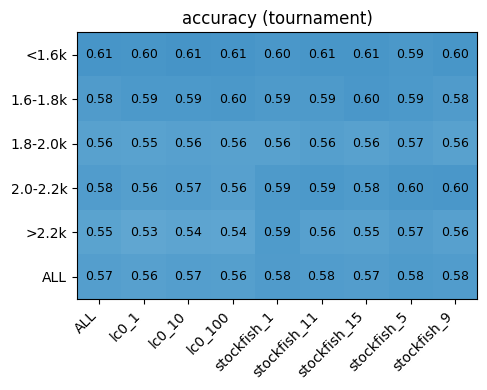

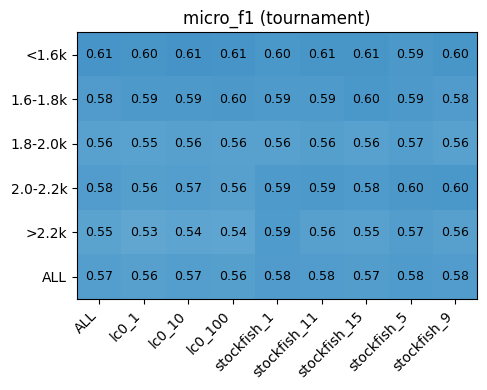

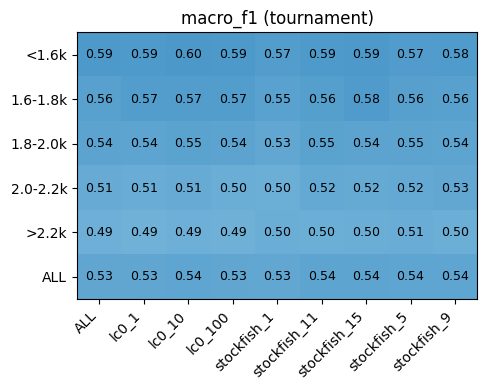

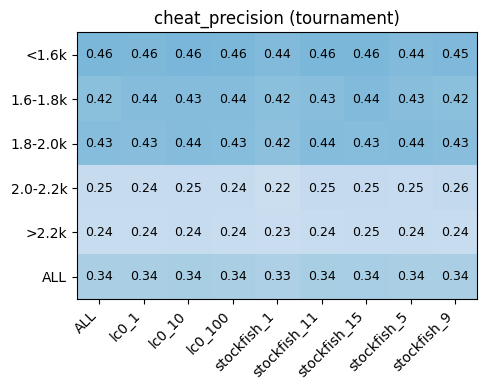

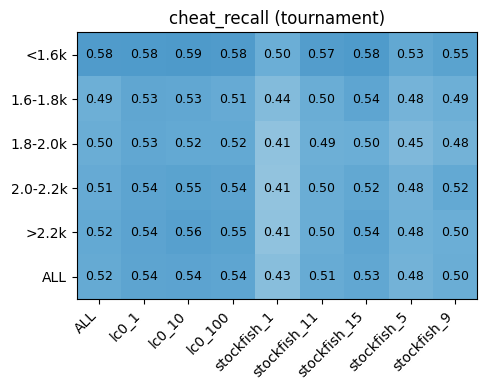

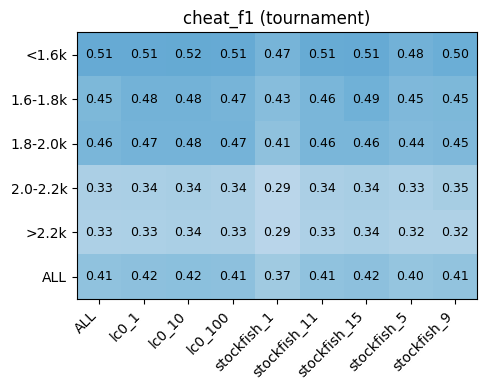

In [8]:
# === Heatmaps (same style as before) ===
import matplotlib.pyplot as plt

def plot_metric_heatmap(
    tbl: pd.DataFrame,
    *,
    title: str,
    out_path: Path,
    vmin: float = 0.0,
    vmax: float = 1.0,
    figsize: tuple[int, int] = (10, 6),
    show_values: bool = True,
) -> None:
    out_path.parent.mkdir(parents=True, exist_ok=True)

    mat = tbl.to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=figsize)
    _im = ax.imshow(mat, vmin=vmin, vmax=vmax, cmap="Blues", interpolation="nearest")

    ax.set_xticks(range(tbl.shape[1]))
    ax.set_yticks(range(tbl.shape[0]))
    ax.set_xticklabels([str(c) for c in tbl.columns], rotation=45, ha="right")
    ax.set_yticklabels([str(r) for r in tbl.index])
    ax.set_title(title)

    if show_values:
        for i in range(tbl.shape[0]):
            for j in range(tbl.shape[1]):
                v = mat[i, j]
                if np.isnan(v):
                    s = ""
                else:
                    s = f"{v:.2f}"
                ax.text(j, i, s, ha="center", va="center", fontsize=9)

    fig.tight_layout()
    fig.savefig(out_path, dpi=150)
    plt.show()

# Pick a compact figsize (4 rows; variable #models)
w = max(10, int(1.2 * len(ALL_COLS)))
figsize = (w, 4)

for mn in metric_names:
    plot_metric_heatmap(
        tables[mn],
        title=f"{mn} (tournament)",
        out_path=OUT_DIR / "curves" / f"heatmap__{mn}.png",
        figsize=figsize,
        show_values=True,
    )
